In [4]:
import time
import torch
import torch.nn as nn

import numpy as np
import matplotlib.pyplot as plt

# import src.learning_gradient_flow.gradient_flow_optimizer as gradient_flow_optimizer
from learning_gradient_flow import gradient_flow_optimizer, adam_flow_optimizer, sindy_tools

torch.manual_seed(0)

def get_flattened_parameters(model: nn.Module) -> torch.Tensor:
    params = []
    for p in model.parameters():
        params.append(p.data.clone().view(-1))
    return torch.cat(params)


class SimpleNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(1, 8),
            nn.Tanh(),
            nn.Linear(8, 1)
        )
    def forward(self, x):
        return self.layers(x)

def true_fcn(x):
    return torch.sin(x * np.pi)

n_models = 10
n_data = 500
nl = 0.0
x = 2 * torch.rand(n_data, 1) - 1
y = true_fcn(x) + nl * torch.randn_like(x)

models = [SimpleNet() for _ in range(n_models)]
baseline_models = [SimpleNet() for _ in range(n_models)]
for i in range(n_models):
    baseline_models[i].load_state_dict(models[i].state_dict())

# print n params
n_params = sum(p.numel() for p in models[0].parameters())
print(f"Number of parameters per model: {n_params}")

Number of parameters per model: 25


In [5]:
# Training loop
epochs = 500
batch_size = n_data
# data loader
train_dataset = torch.utils.data.TensorDataset(x, y)
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
n_batches = len(train_loader)

lr = 0.001
optimizers = []
for i, model in enumerate(models):
    optimizer = torch.optim.SGD(model.parameters(), lr=lr)
    optimizers.append(optimizer)

baseline_optimizers = []
for i, model in enumerate(baseline_models):
    optimizer = torch.optim.SGD(model.parameters(), lr=lr)
    baseline_optimizers.append(optimizer)


def create_closure(model, optimizer):
    def closure():
        x_batch, y_batch = next(iter(train_loader))  # Get a batch of data
        optimizer.zero_grad()
        output = model(x_batch)  # Uses global x, y data
        loss = torch.mean((output - y_batch)**2)
        loss.backward()
        return loss
    return closure

history_size = 20
retrain_interval = 50

sindy_params = sindy_tools.SINDyParams(poly_order=1, method='strong')
batched_sindy_flow = gradient_flow_optimizer.BatchedSINDyFlow(optimizers, lr, history_size=history_size,
                                                              retrain_interval=retrain_interval,
                                                              sindy_params=sindy_params,
                                                              retain_all_states=False)
baseline_batched = gradient_flow_optimizer.BatchedSINDyFlow(baseline_optimizers, lr, history_size=epochs+1,
                                                            retrain_interval=epochs+1,
                                                            sindy_params=sindy_params)

closures = [create_closure(model, optimizer) for model, optimizer in zip(models, optimizers)]
baseline_closures = [create_closure(model, optimizer)
                     for model, optimizer in zip(baseline_models, baseline_optimizers)]
losses = []
baseline_losses = []

for epoch in range(epochs):
    losses_this_epoch = batched_sindy_flow.step(closures)
    baseline_losses_this_epoch = baseline_batched.step(baseline_closures)
    losses.append([loss.item() for loss in losses_this_epoch])
    baseline_losses.append([loss.item() for loss in baseline_losses_this_epoch])

    if epochs < 20 or epoch % (epochs // 20) == 0 or epoch == epochs - 1:
        min_loss = min(losses[-1])
        max_loss = max(losses[-1])
        median_loss = np.median(losses[-1])
        print(f"Epoch {epoch + 1}/{epochs}, min: {min_loss:.4f}, max: {max_loss:.4f}, median: {median_loss:.4f}")
        baseline_min_loss = min(baseline_losses[-1])
        baseline_max_loss = max(baseline_losses[-1])
        baseline_median_loss = np.median(baseline_losses[-1])
        print(f"Baseline, min: {baseline_min_loss:.4f}, "
              f"max: {baseline_max_loss:.4f}, median: {baseline_median_loss:.4f}")

# print the total number of func evals
total_func_evals = batched_sindy_flow.state['func_evals']
baseline_func_evals = baseline_batched.state['func_evals']
print(f"Total function evaluations: {total_func_evals} (vs. {baseline_func_evals}), for {n_models} models, {epochs} epochs")

Epoch 1/500, min: 0.3414, max: 1.0654, median: 0.6473
Baseline, min: 0.3414, max: 1.0654, median: 0.6473
big_rhs_mat shape: torch.Size([180, 26]), big_lhs_target shape: torch.Size([180, 25])
Xi: tensor([[-6.3707e-02, -1.1547e-01, -6.9724e-02, -3.7763e-02, -9.2656e-02,
         -4.1721e-02, -7.1685e-02,  7.4814e-02,  3.2050e-01,  3.3180e-02,
         -2.0077e-01,  6.8826e-01,  3.2848e-02, -5.2451e-01,  5.5926e-01,
          5.5865e-01,  7.2239e-02, -5.5988e-01, -1.7890e-01, -5.5058e-01,
         -4.6524e-02,  1.0298e+00, -2.1505e-01, -1.5257e+00, -1.1952e+00],
        [-2.2447e-01, -6.0845e-02, -6.4837e-02, -8.0923e-02, -3.4699e-01,
         -7.4707e-02, -2.3613e-01,  1.6901e-01, -4.1550e-01, -2.0527e+00,
          3.0347e-01,  1.0407e-01, -1.2402e+00, -3.0977e-01, -1.7285e+00,
         -4.0938e-02, -3.6874e-01, -1.5876e-01, -2.8118e-01,  4.7184e-01,
         -1.5631e+00,  9.6642e-01,  2.5256e+00, -1.4493e+00, -1.2075e+00],
        [ 2.9565e-01, -7.7058e-01,  1.8896e-01,  1.8377e-01, -4

(0.1, 2.0)

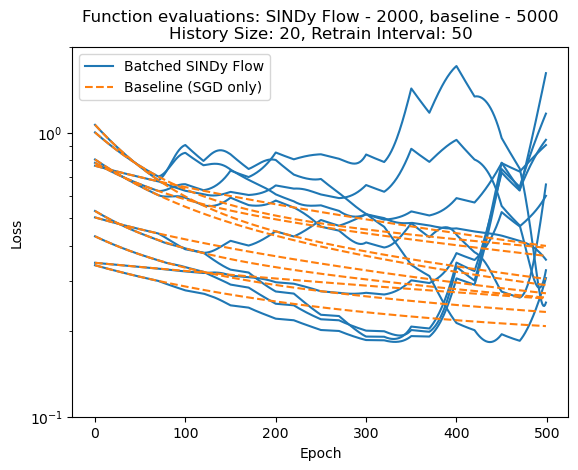

In [6]:
np_losses = np.array(losses)
np_baseline_losses = np.array(baseline_losses)
plt.figure()
p1 = plt.semilogy(np_losses, color='C0')
p2 = plt.semilogy(np_baseline_losses, color='C1', linestyle='--')
plt.xlabel('Epoch')
plt.ylabel('Loss')
# vline = plt.axvline(history_size, color='black', linestyle=':', label='History Size')
# custom legend to avoid repeating for each model
plt.legend([p1[0], p2[0]], ['Batched SINDy Flow', 'Baseline (SGD only)'])
# compare evals in title
# total_func_evals
# comment history size too
plt.title(f"Function evaluations: SINDy Flow - {total_func_evals}, baseline - {baseline_func_evals}"
          f"\nHistory Size: {history_size}, Retrain Interval: {retrain_interval}")
plt.ylim([1e-1, 2e0])